In [ ]:
!pip install einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 340.0 kB/s eta 0:00:00


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
# import packages
import random
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Lambda
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision.utils as vutils
import torch.optim.lr_scheduler as lr_scheduler


In [2]:
# Setting random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# hyperparameters
batch_size = 128
learning_rate = 1e-3
num_epochs = 20
num_steps = 1000
min_beta = 1e-4
max_beta = 0.02
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
result_file = "ddpm1_weidong.pt"

cuda


In [4]:
# download dataset
transform = Compose([ToTensor(), Lambda(lambda x: 2 * x - 1)])
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Failed to download (trying next):
HTTP Error 503: Service Unavailable



100%|██████████| 9912422/9912422 [00:00<00:00, 40067181.85it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 1065463.08it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 503: Service Unavailable



100%|██████████| 1648877/1648877 [00:00<00:00, 9856274.28it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 6513001.29it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [36]:
print(len(loader))

469


In [56]:
# Plot some training images
imgs_batch = next(iter(loader))


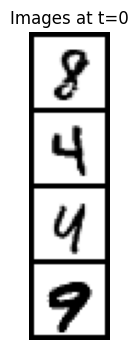

In [57]:
plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("Images at t=0")
plt.imshow(np.transpose(vutils.make_grid(1-imgs_batch[0].to(device)[:4], nrow = 1,padding=2,normalize=True).cpu(),(1,2,0)))

In [58]:
def forward_process(x0_batch, t, min_beta=0.0001, max_beta=0.02, num_steps=1000, eta=None):
        # Make input image more noisy (we can directly skip to the desired step)
        n, c, h, w = x0_batch.shape
        betas = torch.linspace(min_beta, max_beta, num_steps).to(device)
        alphas = 1 - betas
        alpha_bars = torch.tensor([torch.prod(alphas[:i + 1]) for i in range(len(alphas))]).to(device)
        a_bar = alpha_bars[t]

        if eta is None:
            eta = torch.randn(n, c, h, w).to(device)

        noisy = a_bar.sqrt().reshape(n, 1, 1, 1) * x0_batch + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta
        return noisy

In [59]:
noisy = forward_process(imgs_batch[0].to(device), [100 for _ in range(len(imgs_batch[0]))])

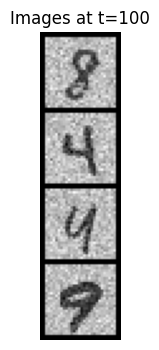

In [60]:
# Plot some training images

plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("Images at t=100")
plt.imshow(np.transpose(vutils.make_grid(1-noisy.to(device)[:4], nrow=1, padding=2, normalize=True).cpu(),(1,2,0)))

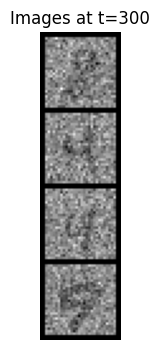

In [61]:
noisy = forward_process(imgs_batch[0].to(device), [300 for _ in range(len(imgs_batch[0]))])
plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("Images at t=300")
plt.imshow(np.transpose(vutils.make_grid(1-noisy.to(device)[:4], nrow=1, padding=2, normalize=True).cpu(),(1,2,0)))

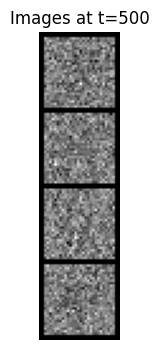

In [63]:
noisy = forward_process(imgs_batch[0].to(device), [500 for _ in range(len(imgs_batch[0]))])
plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("Images at t=500")
plt.imshow(np.transpose(vutils.make_grid(1-noisy.to(device)[:4], nrow=1, padding=2, normalize=True).cpu(),(1,2,0)))

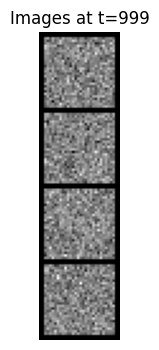

In [64]:
noisy = forward_process(imgs_batch[0].to(device), [999 for _ in range(len(imgs_batch[0]))])
plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("Images at t=999")
plt.imshow(np.transpose(vutils.make_grid(1-noisy.to(device)[:4], nrow=1, padding=2, normalize=True).cpu(),(1,2,0)))

In [5]:
def sinusoidal_embedding(seq_len, d, n=10000):
    # Returns the standard positional embedding
    # https://machinelearningmastery.com/
    embedding = torch.zeros(seq_len, d)
    temp = torch.tensor([1 / n ** ( j / d) for j in range(d)])
    temp = temp.reshape((1, d))
    k = torch.arange(seq_len).reshape((seq_len, 1))
    # temp[:,::2] take even index in the second dimension
    # embedding[:,1::2] take odd index in the second dimension
    embedding[:,::2] = torch.sin(k * temp[:,::2])
    embedding[:,1::2] = torch.cos(k * temp[:,::2])

    return embedding


In [ ]:
example = sinusoidal_embedding(seq_len=4, d=4, n=100)
print(example)

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0998,  0.9950],
        [ 0.9093, -0.4161,  0.1987,  0.9801],
        [ 0.1411, -0.9900,  0.2955,  0.9553]])


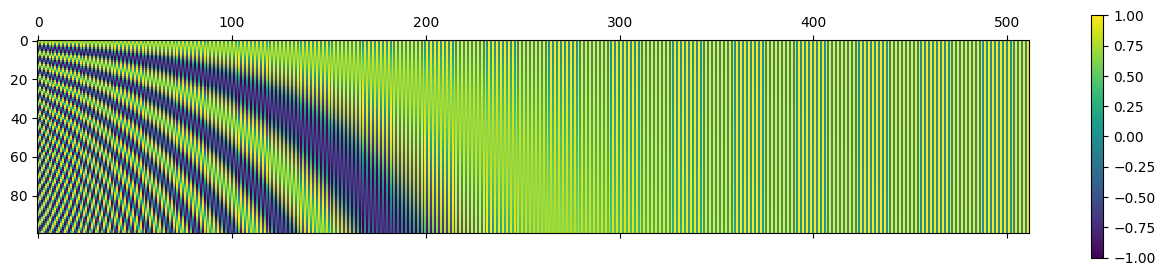

In [6]:
P = sinusoidal_embedding(seq_len=100, d=512)
cax = plt.matshow(P)
plt.gcf().colorbar(cax)

In [7]:
class ResBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super(ResBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out1 = self.conv1(out)
        out = self.activation(out1)
        out = self.conv2(out)
        out = self.activation(out+out1)  # residual connection
        return out

In [8]:
class UNet(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100):
        super(UNet, self).__init__()

        # Sinusoidal embedding
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # First half
        self.te1 = self.net_te(time_emb_dim, 1)
        self.b1 = nn.Sequential(
            ResBlock((1, 28, 28), 1, 32)
        )
        self.down1 = nn.Conv2d(32, 32, 4, 2, 1)

        self.te2 = self.net_te(time_emb_dim, 32)
        self.b2 = nn.Sequential(
            ResBlock((32, 14, 14), 32, 64)
        )
        self.down2 = nn.Conv2d(64, 64, 4, 2, 1)

        self.te3 = self.net_te(time_emb_dim, 64)
        self.b3 = nn.Sequential(
            ResBlock((64, 7, 7), 64, 128)
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(128, 128, 2, 1),
            nn.SiLU(),
            nn.Conv2d(128, 128, 4, 2, 1)
        )

        # Bottleneck
        self.te_mid = self.net_te(time_emb_dim, 128)
        self.b_mid = nn.Sequential(
            ResBlock((128, 3, 3), 128, 128)
        )

        # Second half
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, 2, 1),
            nn.SiLU(),
            nn.ConvTranspose2d(128, 128, 2, 1)
        )

        self.te4 = self.net_te(time_emb_dim, 256)
        self.b4 = nn.Sequential(
            ResBlock((256, 7, 7), 256, 64)
        )

        self.up2 = nn.ConvTranspose2d(64, 64, 4, 2, 1)
        self.te5 = self.net_te(time_emb_dim, 128)
        self.b5 = nn.Sequential(
            ResBlock((128, 14, 14), 128, 32)
        )

        self.up3 = nn.ConvTranspose2d(32, 32, 4, 2, 1)
        self.te_out = self.net_te(time_emb_dim, 64)
        self.b_out = nn.Sequential(
            ResBlock((64, 28, 28), 64, 32, normalize=False)
        )

        self.conv_out = nn.Conv2d(32, 1, 3, 1, 1)

    def forward(self, x, t):

        t = self.time_embed(t)
        n = len(x)
        out1 = self.b1(x + self.te1(t).reshape(n, -1, 1, 1))  # (N, 32, 28, 28)
        out2 = self.b2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  # (N, 64, 14, 14)
        out3 = self.b3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1))  # (N, 128, 7, 7)

        out_mid = self.b_mid(self.down3(out3) + self.te_mid(t).reshape(n, -1, 1, 1))  # (N, 128, 3, 3)

        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # (N, 256, 7, 7)
        out4 = self.b4(out4 + self.te4(t).reshape(n, -1, 1, 1))  # (N, 64, 7, 7)

        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # (N, 128, 14, 14)
        out5 = self.b5(out5 + self.te5(t).reshape(n, -1, 1, 1))  # (N, 32, 14, 14)

        out = torch.cat((out1, self.up3(out5)), dim=1)  # (N, 64, 28, 28)
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))  # (N, 32, 28, 28)

        out = self.conv_out(out)  # (N, 1, 28, 28)

        return out

    def net_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out)
        )

In [9]:
# DDPM class
class DDPM(nn.Module):
    #def __init__(self, network, n_steps=200, min_beta=1E-4, max_beta=0.02, device=None, image_chw=(1, 28, 28)):
    def __init__(self, network, n_steps=200, min_beta=1E-4, max_beta=0.02, device=None):
        super(DDPM, self).__init__()
        self.n_steps = n_steps
        self.device = device
        #self.image_chw = image_chw
        self.network = network.to(device)
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.tensor([torch.prod(self.alphas[:i + 1]) for i in range(len(self.alphas))]).to(device)

    def forward(self, x0, t, eta=None):
        # Generate nosiy images at t
        n, c, h, w = x0.shape
        a_bar = self.alpha_bars[t]

        if eta is None:
            eta = torch.randn(n, c, h, w).to(self.device)

        noisy = a_bar.sqrt().reshape(n, 1, 1, 1) * x0 + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta
        return noisy

    def backward(self, x, t):
        # The network is UNet
        # and returns its estimation of the noise that was added.
        return self.network(x, t)

In [22]:
# Defining model

n_steps = num_steps  # 1000 see hyperparameters
ddpm = DDPM(UNet(n_steps), n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device)

In [11]:
sum([p.numel() for p in ddpm.parameters()])

2134568

In [23]:
# define training_loop
def training_loop(ddpm, loader, n_epochs, learning_rate, device, store_path="ddpm_model.pt"):
    mse = nn.MSELoss()
    best_loss = float("inf")
    n_steps = ddpm.n_steps

    optim = Adam(ddpm.parameters(), lr=learning_rate)
    scheduler = lr_scheduler.LinearLR(optim, start_factor=1.0, end_factor=0.1, total_iters=20)

    for epoch in tqdm(range(n_epochs), desc=f"Training progress", colour="#00ff00"):
        epoch_loss = 0.0
        for step, batch in enumerate(loader):
            # Loading data
            x0 = batch[0].to(device)
            n = len(x0)


            # Generating noise and a random timestp for each of the images in the batch
            eta = torch.randn_like(x0).to(device)
            t = torch.randint(0, n_steps, (n,)).to(device)

            # Computing the noisy image based on x0, noise and the timestep (forward process)
            noisy_imgs = ddpm(x0, t, eta)

            # Estimating noise based on the images and the time-step
            eta_theta = ddpm.backward(noisy_imgs, t.reshape(n, -1))

            # Optimizing the MSE between the noise plugged and the predicted noise
            loss = mse(eta_theta, eta)
            optim.zero_grad()
            loss.backward()
            optim.step()

            epoch_loss += loss.item() * len(x0) / len(loader.dataset)


        # Learning rate scheduling
        before_lr = optim.param_groups[0]["lr"]
        scheduler.step()
        after_lr = optim.param_groups[0]["lr"]
        print("Epoch %d: SGD lr %.7f -> %.7f" % (epoch, before_lr, after_lr))

        log_string = f"Loss at epoch {epoch + 1}: {epoch_loss:.3f}"

        # Storing the model
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(ddpm.state_dict(), store_path)
            log_string += " --> Best model so far (saved)"

        print(log_string)

In [24]:
# run the training_loop
training_loop(ddpm, loader, n_epochs=40, learning_rate=0.001, device=device, store_path=result_file)

Training progress:   2%|▎         | 1/40 [00:16<10:24, 16.02s/it]

Epoch 0: SGD lr 0.0010000 -> 0.0009550
Loss at epoch 1: 0.091 --> Best model so far (saved)


Training progress:   5%|▌         | 2/40 [00:32<10:27, 16.51s/it]

Epoch 1: SGD lr 0.0009550 -> 0.0009100
Loss at epoch 2: 0.046 --> Best model so far (saved)


Training progress:   8%|▊         | 3/40 [00:49<10:06, 16.40s/it]

...

Epoch 37: SGD lr 0.0001000 -> 0.0001000
Loss at epoch 38: 0.026


Training progress:  98%|█████████▊| 39/40 [10:31<00:16, 16.25s/it]

Epoch 38: SGD lr 0.0001000 -> 0.0001000
Loss at epoch 39: 0.025


Training progress: 100%|██████████| 40/40 [10:47<00:00, 16.20s/it]

Epoch 39: SGD lr 0.0001000 -> 0.0001000
Loss at epoch 40: 0.026


In [25]:
# Loading the trained model
best_model = DDPM(UNet(), n_steps=num_steps, device=device)
best_model.load_state_dict(torch.load(result_file, map_location=device))
best_model.eval()
print("Model loaded")

Model loaded


In [71]:
with torch.no_grad():
        if device is None:
            device = ddpm.device

        # Starting from random noise
        n_samples = 64
        c=1
        h=28
        w=28
        x = torch.randn(n_samples, c, h, w).to(device)

        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            # Estimating noise to be removed
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)

            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]

            # Partially denoising the image (Algorithm)
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)

            if t > 0:
                z = torch.randn(n_samples, c, h, w).to(device)

                # Simple Option: sigma_t squared = beta_t
                beta_t = ddpm.betas[t]
                sigma_t = beta_t.sqrt()

                # Adding some more noise like in Langevin Dynamics fashion
                x = x + sigma_t * z


        # Putting the result x in range [0, 255]
        normalized = x.clone()
        for i in range(len(normalized)):
          normalized[i] -= torch.min(normalized[i])
          normalized[i] *= 255 / torch.max(normalized[i])



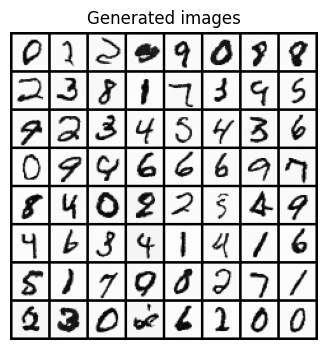

In [72]:

plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("Generated images")
plt.imshow(np.transpose(vutils.make_grid(1-normalized.to(device), nrow=8, padding=2, normalize=True).cpu(),(1,2,0)))

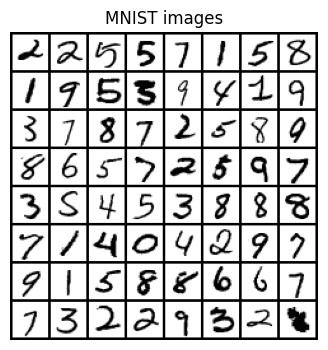

In [38]:
plt.figure(figsize=(4,4))
plt.axis("off")
plt.title("MNIST images")
plt.imshow(np.transpose(vutils.make_grid(1-imgs_batch[0].to(device)[:64], nrow = 8,padding=2,normalize=True).cpu(),(1,2,0)))